# Sparse variational Markov GP

`SparseMarkovGPPrior` is the inducing-time-grid analogue of `MarkovGPPrior`. It wraps any `SDEKernel` and a sorted inducing grid `Z` of length `M`, exposing the standard SVGP building blocks $(K_{ZZ}, K_{xZ}, \mathrm{diag}\,K_{xx})$ derived from the SDE autocovariance $k(\tau) = H \exp(F\tau) P_\infty H^\top$.

Because the predictive-block contract matches the dense `SparseGPPrior`, the existing variational guides (`FullRankGuide`, `MeanFieldGuide`, `WhitenedGuide`) plug straight in. The `sparse_markov_elbo` function delivers a Gaussian-likelihood closed-form ELBO and accepts a `gaussx` integrator for non-conjugate likelihoods.

Cost: $O(M^3 + N M)$ per ELBO evaluation. A truly linear-in-$N$ Kalman-aware ELBO (BayesNewton / MarkovFlow style) is a follow-up.

In [1]:
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np

from pyrox.gp import (
    FullRankGuide,
    GaussianLikelihood,
    MarkovGPPrior,
    MaternSDE,
    SparseConditionedMarkovGP,
    SparseMarkovGPPrior,
    sparse_markov_elbo,
)


plt.rcParams["figure.dpi"] = 110
key = jr.PRNGKey(0)

/home/azureuser/localfiles/pyrox/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Synthetic regression data

Noisy mixture of two sinusoids on an irregular time grid.

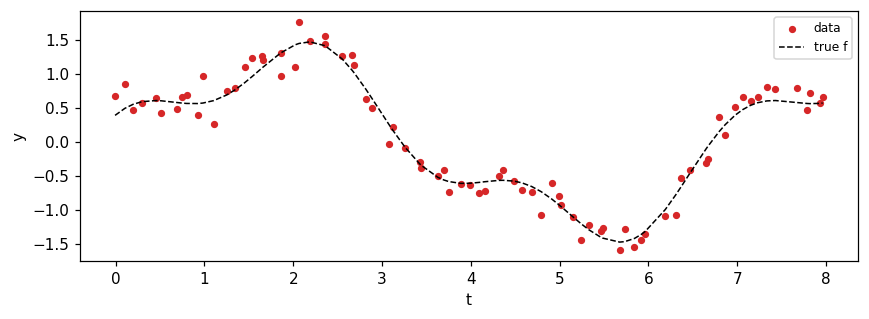

In [2]:
N = 80
t_uniform = jnp.linspace(0.0, 8.0, N)
times = jnp.sort(t_uniform + 0.04 * jr.normal(jr.PRNGKey(1), (N,)))
f_true = 1.2 * jnp.sin(0.9 * times) + 0.4 * jnp.cos(2.7 * times)
y = f_true + 0.18 * jr.normal(key, (N,))

fig, ax = plt.subplots(figsize=(8, 3))
ax.scatter(times, y, c="C3", s=14, label="data")
ax.plot(times, f_true, "k--", lw=1, label="true f")
ax.set_xlabel("t")
ax.set_ylabel("y")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Sparse Markov GP setup

Pick `M = 12` evenly-spaced inducing times and a Matern-3/2 SDE prior. The variational guide is a `FullRankGuide` over the inducing function values $u = f(Z)$.

In [3]:
M = 12
Z = jnp.linspace(times[0], times[-1], M)
sde = MaternSDE(variance=1.0, lengthscale=0.6, order=1)
prior = SparseMarkovGPPrior(sde, Z, jitter=1e-6)
guide = FullRankGuide.init(M, scale=0.3)
lik = GaussianLikelihood(noise_var=0.05)

print(f"M (inducing) = {M}")
print(f"N (data)     = {N}")
print(f"prior marginal variance = {float(prior._stationary_variance()):.3f}")
print(f"initial ELBO = {float(sparse_markov_elbo(prior, guide, lik, times, y)):.3f}")

M (inducing) = 12
N (data)     = 80


prior marginal variance = 1.000


initial ELBO = -771.188


## Conjugate update — closed-form q(u) for Gaussian likelihood

For Gaussian observations the optimal $q(u) = \mathcal{N}(m_q, S_q)$ is closed-form (Titsias 2009):

$$S_q = (\sigma^{-2} K_{ZZ}^{-1} K_{ZX} K_{XZ} K_{ZZ}^{-1} + K_{ZZ}^{-1})^{-1},\qquad
m_q = \sigma^{-2} S_q K_{ZZ}^{-1} K_{ZX}\,(y - \mu).$$

This sidesteps the need to optimise the ELBO and gives the optimal $q(u)$ at the prescribed inducing locations directly. We use it here to demonstrate the `sparse_markov_elbo` / `SparseConditionedMarkovGP` API on a fitted guide.

In [4]:
import equinox as eqx


K_zz_op, K_xz, _K_xx_diag = prior.predictive_blocks(times)
K_zz = K_zz_op.as_matrix()
sigma2 = 0.05  # observation variance
mu_x = prior.mean(times)

# A = K_zz^{-1} K_xz^T   (M, N)
A = jnp.linalg.solve(K_zz, K_xz.T)
# Posterior precision in the inducing-value coords:
# Lambda_q = K_zz^{-1} + sigma^{-2} A A^T
Lambda_q = jnp.linalg.inv(K_zz) + (1.0 / sigma2) * A @ A.T
S_q = jnp.linalg.inv(Lambda_q)
m_q = (1.0 / sigma2) * S_q @ A @ (y - mu_x)

# Build a guide carrying that closed-form posterior.
L_q = jnp.linalg.cholesky(0.5 * (S_q + S_q.T) + 1e-9 * jnp.eye(M))
guide = eqx.tree_at(
    lambda g: (g.mean, g.scale_tril),
    guide,
    replace=(m_q, L_q),
)
print(
    f"closed-form ELBO = {float(sparse_markov_elbo(prior, guide, lik, times, y)):.3f}"
)

closed-form ELBO = -101.641


## Posterior at the fitted guide

`SparseConditionedMarkovGP.predict(t_star)` produces the mean / variance at arbitrary test times via the standard SVGP predictive (cost $O(M^3 + |t_*|\,M)$).

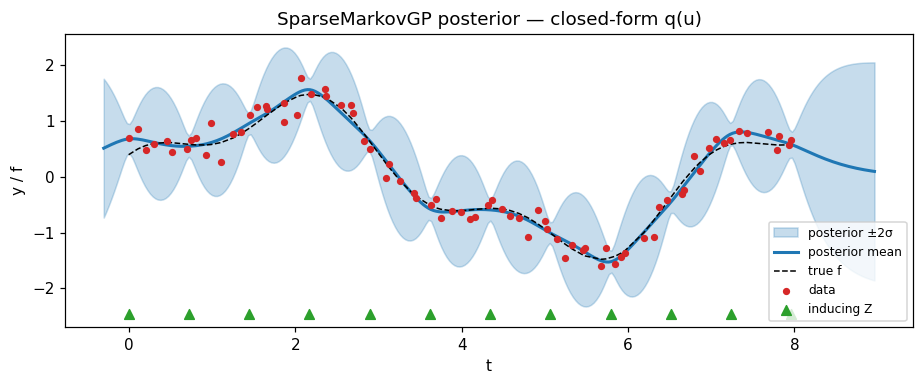

In [5]:
cond = SparseConditionedMarkovGP(prior=prior, guide=guide)
t_star = jnp.linspace(times[0] - 0.3, times[-1] + 1.0, 300)
m_star, v_star = cond.predict(t_star)
m_star, v_star = np.asarray(m_star), np.asarray(v_star)
sd_star = np.sqrt(np.maximum(v_star, 0))

fig, ax = plt.subplots(figsize=(8.5, 3.6))
ax.fill_between(
    t_star,
    m_star - 2 * sd_star,
    m_star + 2 * sd_star,
    color="C0",
    alpha=0.25,
    label="posterior ±2σ",
)
ax.plot(t_star, m_star, color="C0", lw=2, label="posterior mean")
ax.plot(times, f_true, "k--", lw=1, label="true f")
ax.scatter(times, y, c="C3", s=14, label="data", zorder=3)
ax.scatter(
    Z,
    jnp.full_like(Z, ax.get_ylim()[0] + 0.1),
    c="C2",
    marker="^",
    s=40,
    label="inducing Z",
)
ax.set_xlabel("t")
ax.set_ylabel("y / f")
ax.set_title("SparseMarkovGP posterior — closed-form q(u)")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

## Comparison: sparse vs dense Markov GP

At the closed-form $q(u)$ and well-spaced inducing points, the SVGP posterior should approximate the dense-Markov posterior. The remaining difference is the inducing-set bias from working with $M = 12$ pseudo-points instead of all $N = 80$ data points.

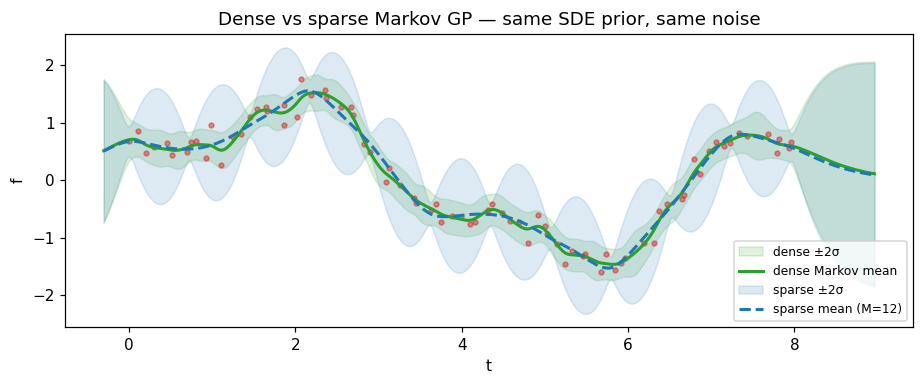

max |sparse mean − dense mean| = 0.2002


In [6]:
dense_prior = MarkovGPPrior(sde, times)
dense_cond = dense_prior.condition(y, jnp.asarray(0.05))
m_dense, v_dense = dense_cond.predict(t_star)
m_dense, v_dense = np.asarray(m_dense), np.asarray(v_dense)
sd_dense = np.sqrt(np.maximum(v_dense, 0))

fig, ax = plt.subplots(figsize=(8.5, 3.6))
ax.fill_between(
    t_star,
    m_dense - 2 * sd_dense,
    m_dense + 2 * sd_dense,
    color="C2",
    alpha=0.15,
    label="dense ±2σ",
)
ax.plot(t_star, m_dense, color="C2", lw=2, label="dense Markov mean")
ax.fill_between(
    t_star,
    m_star - 2 * sd_star,
    m_star + 2 * sd_star,
    color="C0",
    alpha=0.15,
    label="sparse ±2σ",
)
ax.plot(t_star, m_star, color="C0", lw=2, ls="--", label=f"sparse mean (M={M})")
ax.scatter(times, y, c="C3", s=10, alpha=0.5)
ax.set_xlabel("t")
ax.set_ylabel("f")
ax.set_title("Dense vs sparse Markov GP — same SDE prior, same noise")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

print(
    f"max |sparse mean − dense mean| = {float(jnp.max(jnp.abs(m_star - m_dense))):.4f}"
)

## Sweep: how many inducing points do we need?

Increase `M` and re-fit the closed-form $q(u)$. Past a kernel-dependent threshold, the sparse posterior is indistinguishable from the dense one.

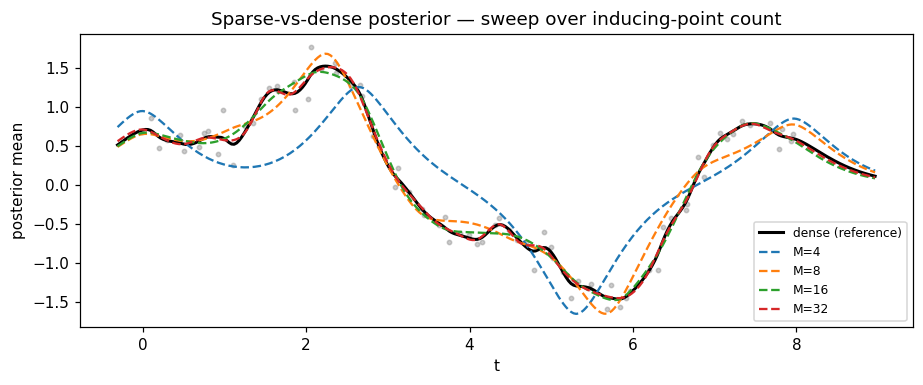

In [7]:
def fit_sparse(M_: int) -> SparseConditionedMarkovGP:
    Z_ = jnp.linspace(times[0], times[-1], M_)
    prior_ = SparseMarkovGPPrior(sde, Z_, jitter=1e-6)
    K_zz_op_, K_xz_, _ = prior_.predictive_blocks(times)
    K_zz_ = K_zz_op_.as_matrix()
    A_ = jnp.linalg.solve(K_zz_, K_xz_.T)
    Lambda_ = jnp.linalg.inv(K_zz_) + (1.0 / sigma2) * A_ @ A_.T
    S_ = jnp.linalg.inv(Lambda_)
    m_ = (1.0 / sigma2) * S_ @ A_ @ (y - prior_.mean(times))
    L_ = jnp.linalg.cholesky(0.5 * (S_ + S_.T) + 1e-9 * jnp.eye(M_))
    g_ = eqx.tree_at(
        lambda g: (g.mean, g.scale_tril),
        FullRankGuide.init(M_, scale=0.3),
        replace=(m_, L_),
    )
    return SparseConditionedMarkovGP(prior=prior_, guide=g_)


fig, ax = plt.subplots(figsize=(8.5, 3.6))
ax.plot(t_star, m_dense, color="black", lw=2, label="dense (reference)")
for M_, color in zip([4, 8, 16, 32], ["C0", "C1", "C2", "C3"], strict=True):
    cond_ = fit_sparse(M_)
    m_, _ = cond_.predict(t_star)
    ax.plot(t_star, np.asarray(m_), color=color, lw=1.5, ls="--", label=f"M={M_}")
ax.scatter(times, y, c="grey", s=8, alpha=0.4)
ax.set_xlabel("t")
ax.set_ylabel("posterior mean")
ax.set_title("Sparse-vs-dense posterior — sweep over inducing-point count")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

## Summary

- `SparseMarkovGPPrior(sde_kernel, Z)` exposes the SVGP predictive blocks for any state-space kernel.
- `sparse_markov_elbo(...)` plugs into the existing variational-guide infrastructure with a closed-form Gaussian-likelihood path and a numerical (gaussx-integrator) path for non-conjugate likelihoods.
- For Gaussian observations the optimal $q(u)$ is closed-form (used here for demonstration); for non-conjugate likelihoods, optimise `sparse_markov_elbo` via standard SVI (see `markov_gp_training.ipynb` for the optax-LBFGS pattern wrapping the SDE forward pass under JIT, which is the canonical way to train through the dynamic-stop expm in `SDEKernel.discretise`).
- At $M$ large enough to span the posterior support of the kernel, the sparse posterior collapses to the dense one. Reducing $M$ trades fidelity for the $O(M^3)$ ELBO cost.
- This surface is the SVGP-style foundation. A truly linear-in-$N$ Kalman-aware ELBO that exploits the Markov factorisation of $q(u)$ is a follow-up.